<a href="https://colab.research.google.com/github/AllenSWDB/TReND-CaMinA/blob/main/notebooks/Kenya26/03_04-Wed1toThu2-AllenTutorial/project_templates/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project** 1

### How well can you predict which brain region a neuron is in based on its activity?

This dataset surveyed visual responses across six different visual areas. One of the key questions we can ask is how the neural responses differ across these areas? There have been several studies that have looked at this, both using these data as well as other data. Two papers that motivated this study were published back-to-back: [Marshel, Garrett et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01046-4?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010464%3Fshowall%3Dtrue) and [Andermann et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01012-9?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010129%3Fshowall%3Dtrue). These two studies compared the tuning properties of neurons in different areas in the mouse visual cortex. They compared area responses using metrics such as orientation selectivity, preferred temporal frequency (TF), and preferred spatial frequency (SF).  Andermann et al particularly focused on the differences between areas AL and PM as these are thought to be parts of the ventral and dorsal visual streams, respectively. [see lecture slides X-Y]

Another notable study, [Kumar et al 2021](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008548), uses the Allen Brain Observatory data to show that neurons can be parcellated into brain regions using short segments of natural movie responses or even spontaneous activity.

The question here is how accurately can you classify neurons into their respective brain regions based on their responses to the drifting grating stimulus?


In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Set up the AllenSDK and point it to the data manifest

In [ ]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [ ]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:  
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X 
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"
        
    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "visual_coding_2p")
    
boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

Get a dataframe of sessions in VISpm, layer 2/3 Cux2 when drifting gratings were shown

In [ ]:
exps_pm = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

Look at the data frame. How long is it?

In [ ]:
exps_pm.head()

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,504115289,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),124,511510817,three_session_A,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True
1,502666254,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),96,511510645,three_session_A,225039,Cux2-CreERT2;Camk2a-tTA;Ai93-225039,True
2,658854537,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),110,658854535,three_session_A,360566,Cux2-CreERT2;Camk2a-tTA;Ai93-360566,False
3,512311673,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),91,511976252,three_session_A,233214,Cux2-CreERT2;Camk2a-tTA;Ai93-233214,True
4,510859641,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),82,511511083,three_session_A,233215,Cux2-CreERT2;Camk2a-tTA;Ai93-233215,False


In [ ]:
len(exps_pm)

9

Now repeat this to get a dataframe of sessions in VISal, layer 2/3 Cux2 when drifting gratings were shown

In [ ]:
exps_al = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

In [ ]:
len(exps_al)

6

Write a function to compute the 2D tuning curve of the neurons within one session to the drifting grating stimulus

In [ ]:
def compute_tuning(session_id):
    #access data for the session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for all cells
    timestamps, dff = data_set.get_dff_traces()
    number_cells = dff.shape[0]
    print("Number of cells: ", number_cells)

    #get the stimulus table for the drifting gratings
    stim_table = data_set.get_stimulus_table('drifting_gratings')

    #get the orivals and tfvals
    all_ori = np.unique(stim_table.orientation)
    orivals = all_ori[np.isfinite(all_ori)]
    tfvals = np.unique(stim_table.temporal_frequency)
    tfvals = tfvals[np.isfinite(tfvals)]

    #compute response per trial for all neurons
    trial_response = pd.DataFrame(index=stim_table.index.values, columns=np.array(range(number_cells)).astype(str))

    for ind,row in stim_table.iterrows():
        for nc in range(number_cells):
            trial_response[str(nc)][ind] = dff[nc,int(row.start):int(row.end)].mean()

    #calculate the response to the blanksweeps:
    blank_response = trial_response[np.isnan(stim_table.orientation)].mean()

    #compute 2D tuning array and subtract the blanksweep response
    tuning_array = np.empty((8,5,number_cells))
    for i,tf in enumerate(tfvals): #iterate across TF
        for j,ori in enumerate(orivals): #iterate across ori
            tuning_array[j,i,:] = trial_response[(stim_table.orientation==ori)&
                                                 (stim_table.temporal_frequency==tf)].mean() - blank_response

    return(dff, stim_table, trial_response, tuning_array)

Let's test this on the first session

In [ ]:
session_id = exps_pm.id[0]
(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)

Number of cells:  94


In [ ]:
tuning_array.shape

(8, 5, 94)

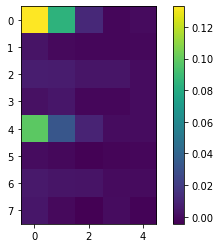

In [ ]:
plt.imshow(tuning_array[:,:,4])
cbar = plt.colorbar()

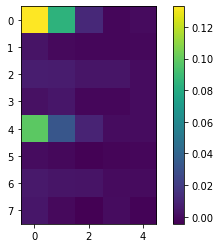

In [ ]:
plt.imshow(tuning_array[:,:,4])
cbar = plt.colorbar()

In [ ]:
ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])

In [ ]:
ta_flatten.shape

(40, 94)

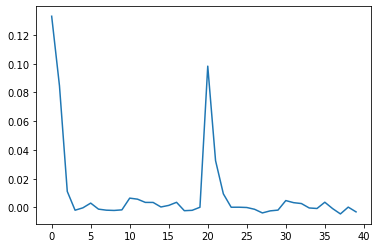

In [ ]:
plt.plot(ta_flatten[:,4])

You can restore the original 2D tuning curve using the `np.reshape` function

In [ ]:
ta_reshape = ta_flatten[:,4].reshape((8,5))

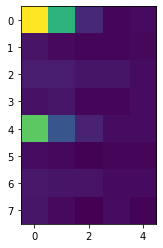

In [ ]:
plt.imshow(ta_reshape[:,:])

Use function to compute 2D tuning array for all PM sessions. Flatten the tuning array from the session, and append the result to a growing list of tuning data.

In [ ]:
#create an empty array to contain the results
tuning_pm = np.empty((40,0))

#for each session
for pmid in exps_pm.id:
    print("Session ID: ", pmid)
    #compute the 2D tuning array
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(pmid)
    #flatten the array from (8,5,numbercells) to (40,numbercells)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    #append the result to the array for results
    tuning_pm = np.append(tuning_pm, ta_flatten, axis=1)

Session ID:  504115289
Number of cells:  94
Session ID:  502666254
Number of cells:  90
Session ID:  658854537
Number of cells:  112
Session ID:  512311673
Number of cells:  70
Session ID:  510859641
Number of cells:  124
Session ID:  503324629
Number of cells:  167
Session ID:  657914280
Number of cells:  84
Session ID:  502376461
Number of cells:  106
Session ID:  506773185
Number of cells:  101


save ths to scratch

In [ ]:
tuning_pm.shape

(40, 948)

Repeat this for the AL data.

In [ ]:
tuning_al = np.empty((40,0))
for alid in exps_al.id:
    print("Session ID: ", alid)
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(alid)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    tuning_al = np.append(tuning_al, ta_flatten, axis=1)

Session ID:  506773892
Number of cells:  76
Session ID:  557225279
Number of cells:  47
Session ID:  503412730
Number of cells:  119
Session ID:  502199136
Number of cells:  159
Session ID:  501876401
Number of cells:  181
Session ID:  501933264
Number of cells:  217


save this array to scratch

In [ ]:
tuning_al.shape

(40, 799)

In [ ]:
label = np.repeat(0,948)

In [ ]:
label = np.append(label, np.repeat(1,799))

In [ ]:
label

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
len(label)

1747

In [ ]:
tuning = np.append(tuning_pm, tuning_al, axis=1)

In [ ]:
tuning.shape

(40, 1747)

We want to select a random subset of these neurons as heldout data to use to test our models. We will create a random list of integers to remove from these arrays. First, set a seed so that we create the same random selection if we rerun this code. Set the seed variable with your favorite number.

In [ ]:
# Create a generator instance with a specific seed
rng = np.random.default_rng(seed=15)

In [ ]:
holdout = np.random.choice(range(1747),200,replace=False)

In [ ]:
tuning_holdout = tuning[:,holdout]

In [ ]:
tuning_holdout.shape

(40, 200)

In [ ]:
label_holdout = label[holdout]
label_holdout.shape

(200,)

In [ ]:
tuning.shape

(40, 1747)

In [ ]:
tuning_train = np.delete(tuning, holdout, axis=1)

In [ ]:
tuning_train.shape

(40, 1547)

In [ ]:
label_train = np.delete(label, holdout)

In [ ]:
len(label_train)

1547